## <center> Даты: основные типы

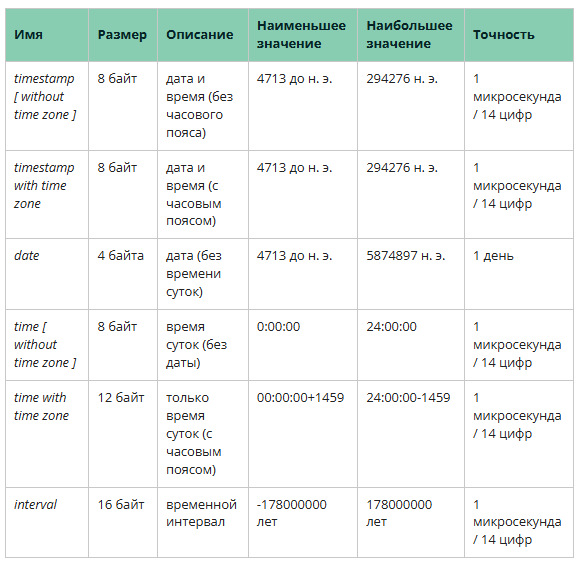

# TIMESTAMP

>**Timestamp** — наиболее распространённый тип данных, так как он содержит и дату, и время, а также используется в любых логах событий, временных рядах и в большинстве системных таблиц.

Согласно стандарту ISO, значение выглядит как "2019-07-14 01:35:44.702165+00", где перечислены через точку год-месяц-день, время и часовой пояс.

ля получения текущего значения даты и времени в Postgres используются функции ```CURRENT_TIMESTAMP``` (есть в стандарте SQL) и ```NOW()``` (есть в большинстве баз данных).

# Timestamp with time zone

>**Timestamp with time zone** позволяет хранить сведения о часовом поясе, что может быть удобно при анализе географически распределённых временных данных для единообразия хранения.

Временные метки лучше всего хранить в базе в едином часовом поясе.

Сначала попробуем узнать, в каком часовом поясе выводятся временные данные в настоящий момент. Для этого выполните команду
```sql
show timezone

А ещё посмотрите ваше время в каком-нибудь часовом поясе, например, в Москве.
```sql
select now() at time zone 'Europe/Moscow'

Чтобы посмотреть информацию обо всех часовых поясах:
```sql
select * from pg_timezone_names

Указание ```at time zone``` позволяет переводить дату/время без часового пояса в дату/время с часовым поясом и обратно, а также пересчитывать значения времени для различных часовых поясов.

В таблице ниже приведены примеры того, как работает ```at time zone``` для разных типов данных.

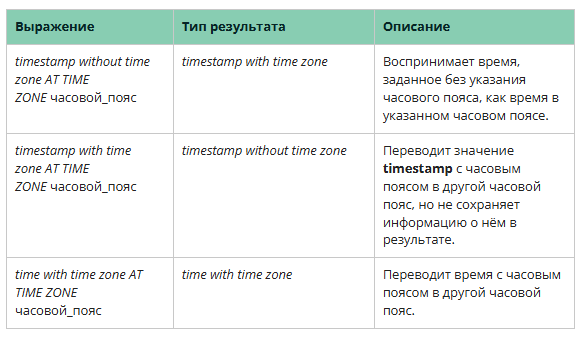

>Давайте узнаем, сколько сейчас времени в другом регионе, например Лос-Анджелесе. Напишите запрос, который выведет текущие время и дату в часовом поясе Лос-Анджелеса ("America/Los_Angeles"). Столбец в выдаче — now (время и дата в нужном часовом поясе).
```sql
select now() at time zone 'America/Los_Angeles' as now

# Date

Тип timestamp (with/without time zone) можно легко перевести в соответствующую дату, используя синтаксис
```sql
"timestamp_column"::date

И наоборот, тип date преобразуется в timestamp (дата и 00:00:00) с помощью
```sql
"date_column"::timestamp

Для получения текущей даты можно использовать
```sql
select CURRENT_DATE

или
```sql
select now()::date

## Обобщённое табличное выражение, оператор WITH

Обобщённое табличное выражение или CTE (Common Table Expressions) - это временный результирующий набор данных, к которому можно обращаться в последующих запросах. Для написания обобщённого табличного выражения используется оператор WITH.
```sql
WITH Aeroflot_trips AS
    (SELECT TRIP.* FROM Company
        INNER JOIN Trip ON Trip.company = Company.id WHERE name = 'Aeroflot')

SELECT plane, COUNT(plane) AS amount FROM Aeroflot_trips GROUP BY plane

Выражение с WITH считается «временным», потому что результат не сохраняется где-либо на постоянной основе в схеме базы данных, а действует как временное представление, которое существует только на время выполнения запроса, то есть оно доступно только во время выполнения операторов SELECT, INSERT, UPDATE, DELETE или MERGE. Оно действительно только в том запросе, которому он принадлежит, что позволяет улучшить структуру запроса, не загрязняя глобальное пространство имён.

Синтаксис оператора WITH:
```sql
WITH название_cte [(столбец_1 [, столбец_2 ] …)] AS (подзапрос)
    [, название_cte [(столбец_1 [, столбец_2 ] …)] AS (подзапрос)] …

Порядок использования оператора WITH:
* Ввести оператор WITH
* Указать название обобщённого табличного выражения
* Опционально: определить названия для столбцов получившегося табличного выражения, разделённых знаком запятой
* Ввести AS и далее подзапрос, результат которого можно будет использовать в других частях SQL запроса, используя имя, определённое на 2 этапе
* Опционально: если необходимо более одного табличного выражения, то ставится запятая и повторяются шаги 2-4

Примеры запросов

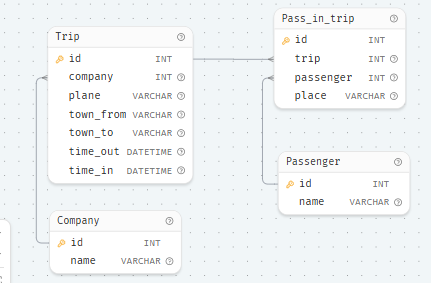


Создаём табличное выражение Aeroflot_trips, содержащее все полёты, совершенные авиакомпанией «Aeroflot»
```sql
WITH Aeroflot_trips AS
    (SELECT plane, town_from, town_to FROM Company
        INNER JOIN Trip ON Trip.company = Company.id WHERE name = 'Aeroflot')

SELECT * FROM Aeroflot_trips;

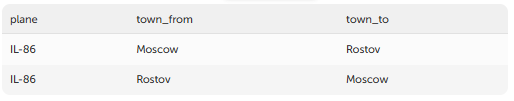

Аналогично, создаём табличное выражение Aeroflot_trips, но с переименованными колонками
```sql
WITH Aeroflot_trips (aeroflot_plane, town_from, town_to) AS
    (SELECT plane, town_from, town_to FROM Company
        INNER JOIN Trip ON Trip.company = Company.id WHERE name = 'Aeroflot')

SELECT * FROM Aeroflot_trips;

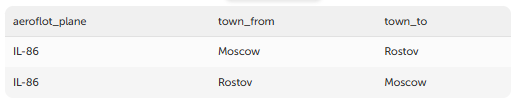

С помощью оператора WITH определяем несколько табличных выражений
```sql
WITH Aeroflot_trips AS
    (SELECT TRIP.* FROM Company
        INNER JOIN Trip ON Trip.company = Company.id WHERE name = 'Aeroflot'),
    Don_avia_trips AS
    (SELECT TRIP.* FROM Company
        INNER JOIN Trip ON Trip.company = Company.id WHERE name = 'Don_avia')

SELECT * FROM Don_avia_trips UNION SELECT * FROM  Aeroflot_trips;

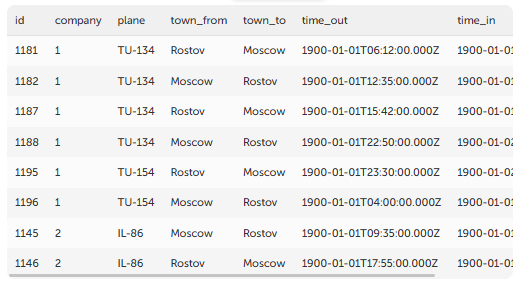

>Предположим, у нас есть дата и время какого-то события и мы хотим посмотреть, к какой дате оно относится для Москвы и для UTC. Используйте следующий подзапрос и выведите дату в ts в Московском часовом поясе и в поясе UTC:

```sql
WITH x AS 
(
SELECT '2018-12-31 21:00:00+00'::timestamp WITH time zone ts
)
SELECT 
        (ts at time zone 'Europe/Moscow')::date dt_msk,
        (ts)::date dt_utc
FROM x

# Interval

>Interval — тип данных, позволяющий хранить разницу между двумя временными метками. 

Интервалы хранят данные в трёх отдельных полях — месяцах, днях, секундах. Это сделано из-за того, что количество дней в месяце и часов в дне может быть разным. Пример значения такого типа: "195 days -10:52:23.563955".

## Функции и операторы для работы с датами

## <center> Функция extract()

>Функция extract() получает из значений даты/времени такие поля, как год или час.

**day**

Для значений timestamp это день месяца (1-31), для значений interval — число дней.
```sql
SELECT EXTRACT(DAY FROM TIMESTAMP '2001-02-16 20:38:40');

```sql
SELECT EXTRACT(DAY FROM INTERVAL '40 days 1 minute');

**hour**

Час (0-23).
```sql
SELECT EXTRACT(HOUR FROM TIMESTAMP '2001-02-16 20:38:40');

**month**

Номер месяца, считая с января (1) до декабря (12).
```sql
SELECT EXTRACT(MONTH FROM TIMESTAMP '2001-02-16 20:38:40');

**year**

Поле года. Учтите, что года 0 не было, и это следует иметь в виду, вычитая из годов нашей эры годы до нашей эры.
```sql
SELECT EXTRACT(YEAR FROM TIMESTAMP '2001-02-16 20:38:40');

**isoyear**

Год по недельному календарю ISO 8601, в который попадает дата (не применимо к интервалам).
```sql
SELECT EXTRACT(ISOYEAR FROM DATE '2006-01-01');

```sql
SELECT EXTRACT(ISOYEAR FROM DATE '2006-01-02');

Год по недельному календарю ISO начинается с понедельника недели, в которой оказывается 4 января, так что в начале января или в конце декабря год по ISO может отличаться от года по григорианскому календарю. Подробнее об этом рассказывается в описании поля week.

**week**

Номер недели в году по недельному календарю ISO 8601. По определению, недели ISO 8601 начинаются с понедельника, а первая неделя года включает 4 января этого года. Другими словами, первый четверг года всегда оказывается в первой неделе этого года.

В системе нумерации недель ISO первые числа января могут относиться к 52-й или 53-й неделе предыдущего года, а последние числа декабря — к первой неделе следующего года.

Например, 2005-01-01 относится к 53-й неделе 2004 г., а 2006-01-01 — к 52-й неделе 2005 г., тогда как 2012-12-31 включается в первую неделю 2013 г.

Поэтому для получения согласованных результатов рекомендуется использовать поле isoyear в паре с week.
```sql
SELECT EXTRACT(WEEK FROM TIMESTAMP '2001-02-16 20:38:40');

**century**
```sql
SELECT EXTRACT(CENTURY FROM TIMESTAMP '2000-12-16 12:21:13');
Результат: 20

SELECT EXTRACT(CENTURY FROM TIMESTAMP '2001-02-16 20:38:40');
Результат: 21

Первый век начался 0001-01-01 00:00:00, хотя люди в то время так и не считали. Это определение распространяется на все страны с григорианским календарём.

Века с номером 0 не было; считается, что 1 наступил после -1.

Если такое положение вещей вас не устраивает, направляйте жалобы по адресу: Ватикан, Собор Святого Петра, Папе Римскому, лично в руки :)

**decade**

Десятилетие.
```sql
SELECT EXTRACT(DECADE FROM TIMESTAMP '2001-02-16 20:38:40');
Результат: 200

**epoch**

Для значений timestamp with time zone это число секунд с 1970-01-01 00:00:00 UTC (может быть отрицательным); для значений date и timestamp это число секунд с 1970-01-01 00:00:00 по местному времени, а для interval — общая длительность интервала в секундах.
```sql
SELECT EXTRACT(EPOCH FROM TIMESTAMP WITH TIME ZONE
'2001-02-16 20:38:40.12-08');
Результат: 982384720.12

SELECT EXTRACT(EPOCH FROM INTERVAL '5 days 3 hours');
Результат: 442800

Преобразовать время эпохи обратно, в значение дата/время, с помощью to_timestamp можно так:

SELECT to_timestamp(982384720.12);
Результат: 2001-02-17 04:38:40.12+00

**dow**

День недели, считая с воскресенья (0) до субботы (6).
```sql
SELECT EXTRACT(DOW FROM TIMESTAMP '2001-02-16 20:38:40');
Результат: 5

Заметьте, что в extract() дни недели нумеруются не так, как в функции to_char(..., 'D').

**doy**

День года (1-365/366).
```sql
SELECT EXTRACT(DOY FROM TIMESTAMP '2001-02-16 20:38:40');
Результат: 47

**isodow**

День недели, считая с понедельника (1) до воскресенья (7).
```sql
SELECT EXTRACT(ISODOW FROM TIMESTAMP '2001-02-18 20:38:40');
Результат: 7

Результат отличается от dow только для воскресенья. Такая нумерация соответствует ISO 8601.

>Давайте посчитаем помесячную статистику по доставкам, используя функцию extract. Напишите запрос, который выведет год, месяц и количество доставок. Отсортируйте по году и по месяцу в порядке возрастания. Столбцы в выдаче: year_n (номер года), month_n (номер месяца), qty (количество доставок).
```sql
select 
extract (YEAR from s.ship_date) year_n, 
extract (MONTH from  s.ship_date) month_n,
count(s.ship_id) qty
from
    sql.shipment s
group by extract (YEAR from s.ship_date),  extract (MONTH from  s.ship_date)
order by 1,2

## <center> Функция to_char()

Функция to_char() нужна для форматирования даты времени и интервалов в нужный текст.

Например, вы хотите вывести год, месяц и день со специфическим разделителем или получить текстовое наименование месяца или дня недели. По результату работы она очень близка к extract(), но больше нацелена именно на форматирование. Ниже вы видите таблицу с примерами вызовов:

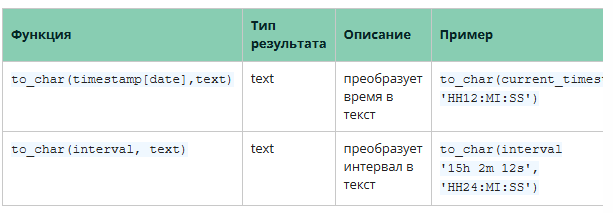

Первый параметр для функции — дата, время или интервал, а второй — текстовая маска получаемого результата. Перечень значений, которые можно использовать для маски, представлен в таблице ниже.

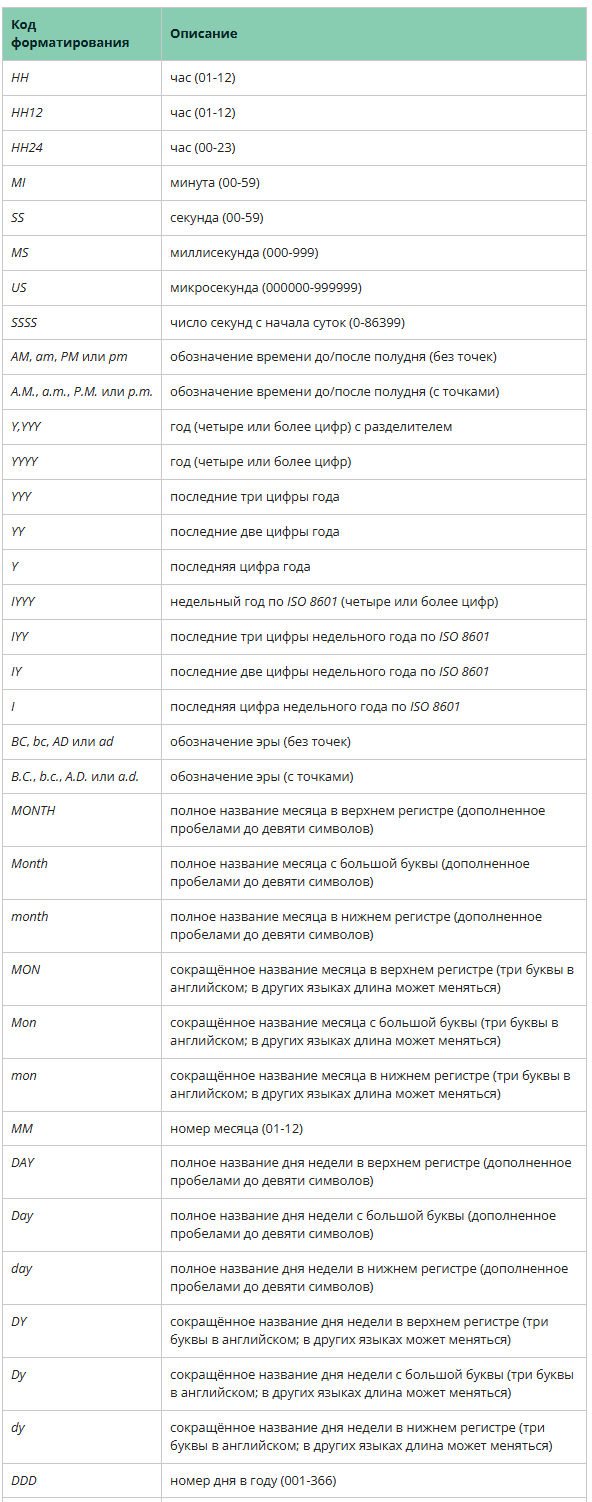
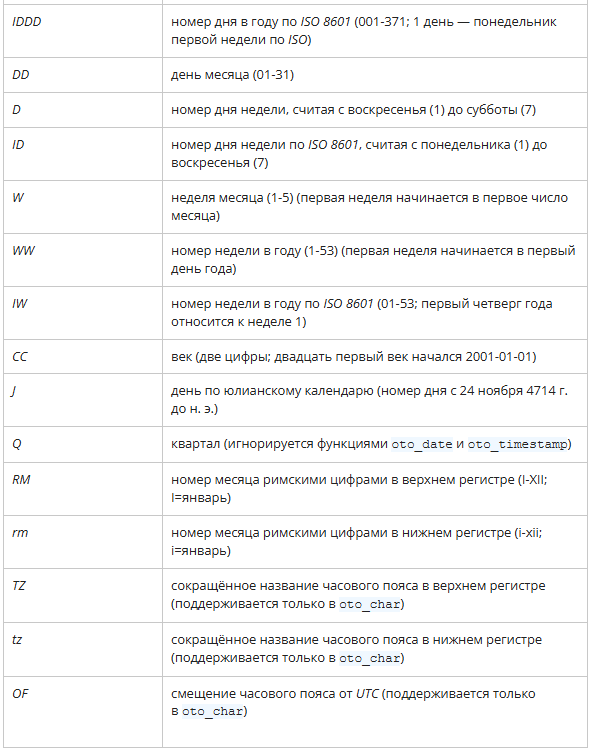

>Любой текст, который относится к кодам форматирования, будет сохранён как есть. Чтобы оставлять какие-то подсказки и использовать обычные буквы, которые не встречаются в таблице выше, необходимо заключить текст, который нужно оставить без изменений, в двойные кавычки.

>Предположим, мы хотим вывести сегодняшнюю дату в формате "Hello! Today is #название дня недели год.название месяца.день#" текстом. Для этого нужно выполнить следующий код: 
```sql
select to_char(now(),'"Hello! Today is" DAY yyyy-Mon-dd')

>Давайте выведем текст текущего времени для сервиса точного времени. Напишите запрос, который выводит текст "Точное время x часов y минут z секунд" (текст в кавычки заключать не нужно), где x, y, z — часы, минуты и секунды соответственно, при условии, что сообщение нужно вывести для московского часового пояса. Время введите в 24-часовом формате. Столбцы в выдаче: msg (сообщение).
```sql
select to_char(now() at time zone 'Europe/Moscow', 'Точное время HH24 часов MI минут SS секунд') msg

## <center> Функция date_trunc()

Функция date_trunc() позволяет отсечь заданное время, дату или дату со временем до нужной точности.

Формат вызова:

 date_trunc('поле', значение)

Например, если мы хотим округлить текущее время-дату до минут, то можно вызвать
```sql
 select date_trunc('minute',now())

Для получения разной степени точности вместо minute можно использовать следующие параметры:
* microseconds;
* milliseconds;
* second;
* minute;
* hour;
* day;
* week;
* month;
* quarter;
* year;
* decade;
* century;
* millennium.


>Давайте подготовим данные для квартальной отчётности компании. Напишите запрос, который выведет дату доставки, округлённую до квартала, и общую массу доставок. Отсортируйте по кварталу в порядке возрастания. Столбцы в выдаче: q (начало квартала, тип date), total_weight (сумма масс доставок за квартал).
```sql
select 
date_trunc('quarter', s.ship_date):: date q,
sum(s.weight) total_weight
from    sql.shipment s
group by 1
order by 1

## <center> Математические операторы

К любой дате можно прибавить (и вычесть из неё) целое число X и получить другую дату, которая больше (меньше) изначальной.

Пример:
```sql
select '2019-01-01'::date + 10
Результат: '2019-01-11'

Это — дата на 10 дней позже 2019-01-01.

При добавлении (или вычитании) целого числа к дате Postgres учитывает переходы между месяцами и годами и даёт верный ответ, соответствующий календарю. Учитываются даже високосные годы.

Пример:
```sql
select '2019-01-01'::date + 500
Результат: '2020-05-15'

Как видим, сменились и год, и месяц, и день.

Аналогично можно вычесть из одной даты другую и получить расстояние в днях между этими датами. При такой операции тоже будет честная разница по календарю.

Пример:
```sql
select '2019-02-10'::date - '2017-03-01'::date
Результат: 711

>Давайте оценим, в каком интервале совершались доставки в разных городах. Напишите запрос, который выведет разницу между последним и первым днём доставки по каждому городу. Отсортируйте по первому и второму столбцам. Столбцы в выдаче: city_name (название города) и days_active (время от первой до последней доставки в днях).
```sql
select
c.city_name,
max(s.ship_date)::date - min(s.ship_date)::date days_active
from
    sql.city c
join sql.shipment s on c.city_id = s.city_id
group by c.city_name
order by 1,2